In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

import random
import os
import time
self_seed = 0
device = torch.device('cpu')#('cuda' if torch.cuda.is_available() else 'cpu')
device_name = torch.cuda.get_device_name(0) if device.type == 'cuda' else 'cpu'
g = torch.Generator(device=device.type).manual_seed(self_seed)
print(f'Using device: {device}')
if device.type == 'cuda':
    print(device_name)

import math

Using device: cpu


In [ ]:
block_sizes = [1,2,3,4,5]       # 上下文长度
embedding_dims = [2,3,4]        # 嵌入维度
hidden_dims = [64, 128, 256]    # 隐藏层大小
batch_sizes = [32, 64, 128]     # 批次数
lr_base = 0.1                   # 初始学习率
max_updates = 200000            # 

In [10]:
pinyins = open('data/names1/names1_pinyin_components.txt','r').read().splitlines()
pinyins_to_chars = open('data/names1/pinyin_components_to_hanzi_chars1.txt','r').read().splitlines()

tokens = [p.split() for p in pinyins]
token_list = sorted({'.'} | {t for token in tokens for t in token})
token_list_len = len(token_list)
stoi = {s:i for i,s in enumerate(token_list)}
itos = {i:s for i,s in enumerate(token_list)}

In [11]:
def build_dataset(data,block_size):
    X,Y = [],[]
    for t in data:
        # print(['.']*block_size + t + ['.'])
        # print(t + ['.'])

        str1 = ['.']*block_size + t + ['.']
        str2 = t + ['.']

        i=0
        for _,y in zip(str1,str2):
            # print(str1[i:i+block_size],y)
            # print([stoi[str1[j]] for j in range(i,i+block_size)],stoi[y])
            X.append([stoi[str1[j]] for j in range(i,i+block_size)])
            Y.append(stoi[y])
            i+=1


    X=torch.tensor(X, device=device)
    Y=torch.tensor(Y, device=device)
    #print(X.shape,Y.shape,X.dtype,Y.dtype)
    return X,Y

In [12]:
def get_lr(lr_base, i, max_steps, warmup_steps=10000, lr_min=1e-5):
    """
    余弦退火学习率
    warmup_steps: 预热步数，前1万步线性增加
    lr_min: 最低学习率，防止后期完全不动
    """
    # 1. 预热阶段：从 0 线性增加到 lr_base
    if i < warmup_steps:
        return lr_base * (i / warmup_steps)
    
    # 2. 余弦退火阶段：从 lr_base 平滑衰减到 lr_min
    # 注意要减去预热步数
    progress = (i - warmup_steps) / (max_steps - warmup_steps)
    # 使用 cosine 公式
    return lr_min + 0.5 * (lr_base - lr_min) * (1.0 + math.cos(math.pi * progress))

In [13]:
def init_model(embedding_dim,block_size):
    E = torch.randn((token_list_len, embedding_dim)        ,generator=g, device=device)
    W1 = torch.randn((block_size*embedding_dim, hidden_dim),generator=g, device=device) * (5/3)/((embedding_dim*block_size)**0.5)*0.4
    b1 = torch.randn(hidden_dim                            ,generator=g, device=device) * 0.2
    W2 = torch.randn((hidden_dim,token_list_len)           ,generator=g, device=device) * 0.01
    b2 = torch.randn(token_list_len                        ,generator=g, device=device) * 0
    return E,W1,b1,W2,b2

@torch.no_grad()
def evaluate(X, Y, E, W1, b1, W2, b2, block_size, embedding_dim):
    emb = E[X]
    h = torch.tanh(emb.view(-1, block_size * embedding_dim) @ W1 + b1)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, Y)
    pred = logits.argmax(dim=1)
    acc = (pred == Y).float().mean()

    return loss.item(), acc.item()

In [14]:
random.seed(self_seed)
tokens_shuffled = tokens[:]
random.shuffle(tokens_shuffled)
n1 = int(0.8*len(tokens_shuffled))
n2 = int(0.9*len(tokens_shuffled))
train_tokens = tokens_shuffled[:n1]
test_tokens = tokens_shuffled[n2:]

all_lossi = []
results = []
model_records = {}
os.makedirs('records/mlp4_models', exist_ok=True)

for block_size in block_sizes:
    for embedding_dim in embedding_dims:
        # print(block_size,embedding_dim)
        # 训练集 80% -> 优化模型权重
        # 测试集 10% -> 测试模型泛化性和准确率
        Xtr,Ytr = build_dataset(train_tokens,block_size)
        Xte,Yte = build_dataset(test_tokens,block_size)

        E,W1,b1,W2,b2 = init_model(embedding_dim,block_size)

        parameters=[E,W1,b1,W2,b2]
        for p in parameters:
            p.requires_grad = True

        # train
        max_steps = 200000
        lossi = []
        train_start_time = time.perf_counter()
        for i in range(max_steps):
            # forward pass
            batch_idxs = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g,device=device)
            emb = E[Xtr[batch_idxs]]
            hpreact = emb.view(-1,block_size*embedding_dim)@W1+b1 # h_practivate
            h = torch.tanh(hpreact)
            logits = h@W2+b2
            loss = F.cross_entropy(logits,Ytr[batch_idxs])

            #backward pass
            for p in parameters:
                p.grad = None
            loss.backward()

            # update
            lr = get_lr(lr_base,i,max_steps)
            for p in parameters:
                p.data += -lr*p.grad
            
            # track stats
            lossi.append(loss.item())

            # print
            if(i%50000==0):
                print(f'[{block_size,embedding_dim}]-> {i:6d}/{max_steps:6d}: loss={loss.item()}')
            #break
        train_time_sec = time.perf_counter() - train_start_time
        train_time_min = train_time_sec / 60

        all_lossi.append({
            'block_size': block_size,
            'embedding_dim': embedding_dim,
            'lossi': lossi,
            'train_time_sec': train_time_sec,
        })

        train_loss, train_acc = evaluate(Xtr, Ytr, E, W1, b1, W2, b2, block_size, embedding_dim)
        test_loss, test_acc = evaluate(Xte, Yte, E, W1, b1, W2, b2, block_size, embedding_dim)
        results.append({
            'block_size': block_size,
            'embedding_dim': embedding_dim,
            'train_loss': train_loss,
            'test_loss': test_loss,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'gap': test_loss - train_loss,
            'train_time_sec': train_time_sec,
            'train_time_min': train_time_min,
            'train_device': device.type,
            'train_device_name': device_name,
        })
        model_path = f'records/mlp4_models/mlp4_bs{block_size}_emb{embedding_dim}.pt'
        model_record = {
            'block_size': block_size,
            'embedding_dim': embedding_dim,
            'model_path': model_path,
            'train_loss': train_loss,
            'test_loss': test_loss,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'gap': test_loss - train_loss,
            'train_time_sec': train_time_sec,
            'train_time_min': train_time_min,
            'train_device': device.type,
            'train_device_name': device_name,
            'params': {
                'E': E.detach().cpu().clone(),
                'W1': W1.detach().cpu().clone(),
                'b1': b1.detach().cpu().clone(),
                'W2': W2.detach().cpu().clone(),
                'b2': b2.detach().cpu().clone(),
            },
        }
        model_records[(block_size, embedding_dim)] = model_record
        torch.save(model_record, model_path)
        print(f'[{block_size,embedding_dim}] train_loss={train_loss:.4f}, test_loss={test_loss:.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}, time={train_time_sec:.1f}s ({train_time_min:.2f}min), device={device_name}')

best_key = min(model_records, key=lambda key: model_records[key]['test_loss'])
best_model = model_records[best_key]
os.makedirs('records', exist_ok=True)
torch.save({
    'results': results,
    'model_records': model_records,
    'best_key': best_key,
    'best_model': best_model,
    'stoi': stoi,
    'itos': itos,
    'token_list': token_list,
}, 'records/mlp4_model_records.pt')
print(f"best_model={best_key}, test_loss={best_model['test_loss']:.4f}, test_acc={best_model['test_acc']:.4f}")
print('saved to records/mlp4_model_records.pt')


[(1, 2)]->      0/200000: loss=4.065332412719727
[(1, 2)]->  50000/200000: loss=1.923845648765564
[(1, 2)]-> 100000/200000: loss=1.9929202795028687
[(1, 2)]-> 150000/200000: loss=2.2627270221710205
[(1, 2)] train_loss=1.9758, test_loss=1.9902, train_acc=0.3421, test_acc=0.3395, time=63.1s (1.05min), device=cpu
[(1, 3)]->      0/200000: loss=4.055508136749268
[(1, 3)]->  50000/200000: loss=2.294889450073242
[(1, 3)]-> 100000/200000: loss=1.7084060907363892
[(1, 3)]-> 150000/200000: loss=1.7987034320831299
[(1, 3)] train_loss=1.9643, test_loss=1.9794, train_acc=0.3430, test_acc=0.3407, time=62.4s (1.04min), device=cpu
[(1, 4)]->      0/200000: loss=4.060461044311523
[(1, 4)]->  50000/200000: loss=2.2568209171295166
[(1, 4)]-> 100000/200000: loss=2.039741277694702
[(1, 4)]-> 150000/200000: loss=1.977620244026184
[(1, 4)] train_loss=1.9634, test_loss=1.9781, train_acc=0.3430, test_acc=0.3407, time=63.6s (1.06min), device=cpu
[(2, 2)]->      0/200000: loss=4.074558258056641
[(2, 2)]->  5000

In [15]:
import pandas as pd

df = pd.DataFrame(results)
df.sort_values('test_loss')

,block_size,embedding_dim,train_loss,test_loss,train_acc,test_acc,gap,train_time_sec,train_time_min,train_device,train_device_name
8,3,4,1.334376,1.364656,0.529158,0.517591,0.030280,65.257944,1.087632,cpu,cpu
7,3,3,1.337602,1.365113,0.529400,0.521260,0.027511,64.491287,1.074855,cpu,cpu
6,3,2,1.343920,1.370925,0.528647,0.520289,0.027005,64.884552,1.081409,cpu,cpu
10,4,3,1.331650,1.373040,0.532653,0.517267,0.041389,64.042048,1.067367,cpu,cpu
9,4,2,1.343318,1.374520,0.529763,0.519534,0.031203,64.960658,1.082678,cpu,cpu
11,4,4,1.326996,1.377859,0.532788,0.516080,0.050863,64.309349,1.071822,cpu,cpu
13,5,3,1.328422,1.378400,0.534172,0.518023,0.049978,64.571283,1.076188,cpu,cpu
12,5,2,1.338028,1.379077,0.532492,0.515541,0.041049,63.348106,1.055802,cpu,cpu
14,5,4,1.323000,1.382603,0.537143,0.515325,0.059603,73.499768,1.224996,cpu,cpu
5,2,4,1.509972,1.531096,0.463905,0.458019,0.021124,63.844462,1.064074,cpu,cpu


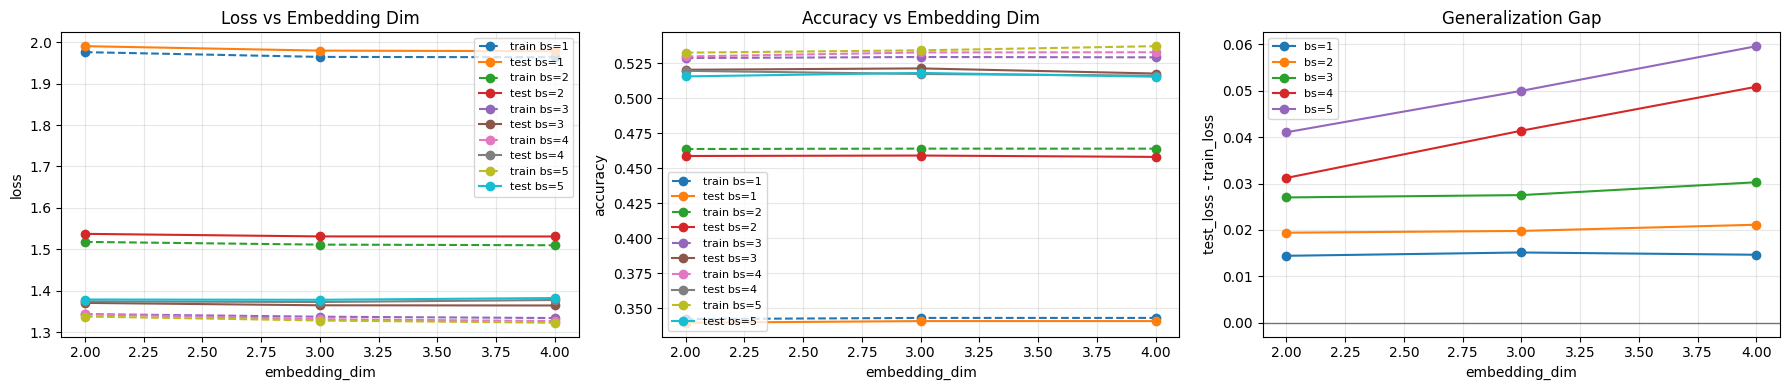

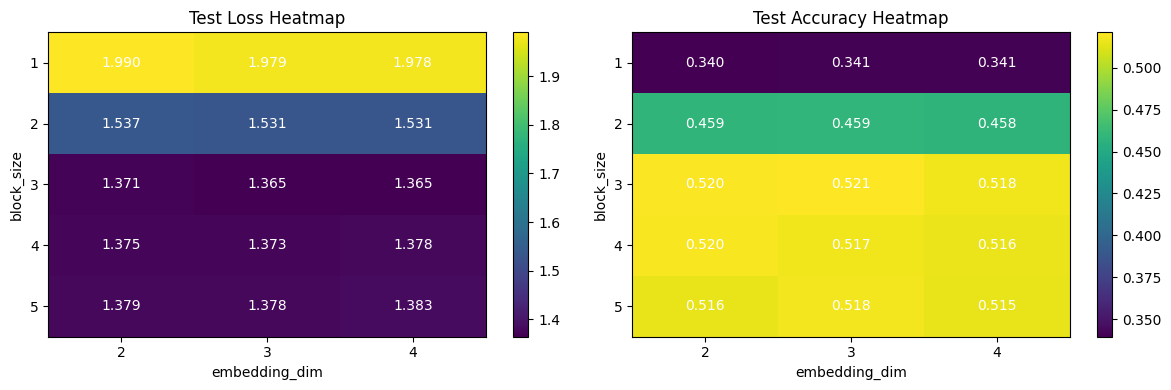

In [16]:
plot_df = df.sort_values(['block_size', 'embedding_dim'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# loss: 训练集和测试集越接近，说明泛化差距越小
for block_size, group in plot_df.groupby('block_size'):
    group = group.sort_values('embedding_dim')
    axes[0].plot(group['embedding_dim'], group['train_loss'], marker='o', linestyle='--', label=f'train bs={block_size}')
    axes[0].plot(group['embedding_dim'], group['test_loss'], marker='o', label=f'test bs={block_size}')

axes[0].set_title('Loss vs Embedding Dim')
axes[0].set_xlabel('embedding_dim')
axes[0].set_ylabel('loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

# accuracy: 给定上下文时，下一个 token 预测正确的比例
for block_size, group in plot_df.groupby('block_size'):
    group = group.sort_values('embedding_dim')
    axes[1].plot(group['embedding_dim'], group['train_acc'], marker='o', linestyle='--', label=f'train bs={block_size}')
    axes[1].plot(group['embedding_dim'], group['test_acc'], marker='o', label=f'test bs={block_size}')

axes[1].set_title('Accuracy vs Embedding Dim')
axes[1].set_xlabel('embedding_dim')
axes[1].set_ylabel('accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

# gap: test_loss - train_loss，越大越可能过拟合
for block_size, group in plot_df.groupby('block_size'):
    group = group.sort_values('embedding_dim')
    axes[2].plot(group['embedding_dim'], group['gap'], marker='o', label=f'bs={block_size}')

axes[2].axhline(0, color='black', linewidth=1, alpha=0.5)
axes[2].set_title('Generalization Gap')
axes[2].set_xlabel('embedding_dim')
axes[2].set_ylabel('test_loss - train_loss')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], 'test_loss', 'Test Loss Heatmap'),
    (axes[1], 'test_acc', 'Test Accuracy Heatmap'),
]:
    pivot = df.pivot(index='block_size', columns='embedding_dim', values=metric)
    im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('embedding_dim')
    ax.set_ylabel('block_size')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', color='white')

    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [17]:
INITIALS = {
    '_', 'b','p','m','f','d','t','n','l','g','k','h',
    'j','q','x','r','z','c','s','y','w','zh','ch','sh'
}

FINALS = {
    'a','o','e','i','u','v',
    'ai','ei','ui','ao','ou','iu','ie','ue','er',
    'an','en','in','un','vn',
    'ang','eng','ing','ong',
    'ia','iao','ian','iang','iong',
    'ua','uo','uai','uan','uang'
}

def is_valid(tokens):
    if tokens.count('|') != 1:
        return False

    sep = tokens.index('|')
    if sep == 0 or sep == len(tokens) - 1:
        return False

    parts = tokens[:sep] + tokens[sep + 1:]
    if len(parts) % 2 != 0:
        return False

    for i in range(0, len(parts), 2):
        if parts[i] not in INITIALS:
            return False
        if parts[i + 1] not in FINALS:
            return False

    return True

def load_component_char_mapping(path):
    mapping = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            key, chars_text = line.split('\t', 1)
            mapping[key] = chars_text.split()
    return mapping

def tokens_to_pinyin(tokens):
    if '|' not in tokens:
        return ' '.join(tokens)
    sep = tokens.index('|')
    left = ' '.join(tokens[:sep])
    right = ' '.join(tokens[sep + 1:])
    return f'{left} | {right}'

def tokens_to_name(tokens, mapping, rng):
    if not is_valid(tokens):
        return None

    sep = tokens.index('|')
    name_parts = []
    for side in (tokens[:sep], tokens[sep + 1:]):
        chars = []
        for i in range(0, len(side), 2):
            key = f'{side[i]} {side[i + 1]}'
            choices = mapping.get(key)
            chars.append(rng.choice(choices) if choices else side[i] + side[i + 1])
        name_parts.append(''.join(chars))
    return ''.join(name_parts)

def load_model_tensors(model_record):
    params = model_record['params']
    return (
        params['E'].to(device),
        params['W1'].to(device),
        params['b1'].to(device),
        params['W2'].to(device),
        params['b2'].to(device),
    )

@torch.no_grad()
def generate_samples(model_record, n=100, max_tokens=20, seed=self_seed):
    block_size = model_record['block_size']
    embedding_dim = model_record['embedding_dim']
    E, W1, b1, W2, b2 = load_model_tensors(model_record)
    sample_g = torch.Generator(device=device.type).manual_seed(seed)

    samples = []
    for _ in range(n):
        has_first_name = False
        out = []
        context = [0] * block_size

        for _ in range(max_tokens):
            x = torch.tensor([context], device=device)
            emb = E[x]
            h = torch.tanh(emb.view(1, -1) @ W1 + b1)
            logits = h @ W2 + b2
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=sample_g).item()
            char = itos[ix]

            if char == '.':
                if has_first_name:
                    break
                continue

            if char == '|':
                if not has_first_name:
                    has_first_name = True
                else:
                    break

            context = context[1:] + [ix]
            out.append(char)

        samples.append(out)

    return samples

if 'model_records' not in globals():
    try:
        checkpoint = torch.load('records/mlp4_model_records.pt', map_location='cpu', weights_only=False)
    except TypeError:
        checkpoint = torch.load('records/mlp4_model_records.pt', map_location='cpu')
    model_records = checkpoint['model_records']
    best_model = checkpoint['best_model']

mapping = load_component_char_mapping('data/names1/pinyin_components_to_hanzi_chars1.txt')

all_sample_rows = []
quality_rows = []

for key, model_record in sorted(model_records.items()):
    block_size = model_record['block_size']
    embedding_dim = model_record['embedding_dim']
    model_label = f'bs={block_size}, emb={embedding_dim}'
    model_prefix = f'bs{block_size}_emb{embedding_dim}'
    samples = generate_samples(model_record, n=100, seed=self_seed)
    name_rng = random.Random(self_seed)
    model_rows = []

    for i, sample in enumerate(samples):
        valid = is_valid(sample)
        name = tokens_to_name(sample, mapping, name_rng)
        row = {
            'block_size': block_size,
            'embedding_dim': embedding_dim,
            'model_label': model_label,
            'model_prefix': model_prefix,
            'idx': i,
            'valid': valid,
            'token_len': len(sample),
            'pinyin_tokens': tokens_to_pinyin(sample),
            'name': name,
        }
        model_rows.append(row)
        all_sample_rows.append(row)

    model_df = pd.DataFrame(model_rows)
    valid_df = model_df[model_df['valid']]
    valid_count = int(model_df['valid'].sum())
    unique_count = int(valid_df['name'].nunique())
    examples = '、'.join(valid_df['name'].dropna().head(8).tolist())
    quality_rows.append({
        'block_size': block_size,
        'embedding_dim': embedding_dim,
        'model_label': model_label,
        'model_prefix': model_prefix,
        'train_loss': model_record['train_loss'],
        'test_loss': model_record['test_loss'],
        'train_acc': model_record['train_acc'],
        'test_acc': model_record['test_acc'],
        'train_time_sec': model_record.get('train_time_sec'),
        'train_time_min': model_record.get('train_time_min'),
        'train_device': model_record.get('train_device'),
        'train_device_name': model_record.get('train_device_name'),
        'valid_count': valid_count,
        'valid_rate': valid_count / len(model_df),
        'unique_count': unique_count,
        'unique_rate': unique_count / max(1, valid_count),
        'avg_token_len': model_df['token_len'].mean(),
        'avg_valid_token_len': valid_df['token_len'].mean() if valid_count else None,
        'examples': examples,
        'model_path': model_record.get('model_path'),
    })

all_sampled_names_df = pd.DataFrame(all_sample_rows)
sample_quality_df = pd.DataFrame(quality_rows)

comparison_rows = []
for idx, idx_df in all_sampled_names_df.groupby('idx'):
    comparison_row = {'idx': idx}
    idx_df = idx_df.sort_values(['block_size', 'embedding_dim'])
    for _, row in idx_df.iterrows():
        prefix = row['model_prefix']
        name = row['name'] if row['valid'] else '<INVALID>'
        comparison_row[prefix] = f"{row['pinyin_tokens']} -> {name}"
    comparison_rows.append(comparison_row)

generated_names_compare_df = pd.DataFrame(comparison_rows).sort_values('idx')
sample_quality_sorted = sample_quality_df.sort_values(
    ['valid_rate', 'unique_rate', 'test_loss'],
    ascending=[False, False, True],
)

all_sampled_names_df.to_csv('records/mlp4_generated_names_by_model.csv', index=False, encoding='utf-8-sig')
generated_names_compare_df.to_csv('records/mlp4_generated_names_compare_wide.csv', index=False, encoding='utf-8-sig')
sample_quality_sorted.to_csv('records/mlp4_sample_quality.csv', index=False, encoding='utf-8-sig')

print('saved generated names to records/mlp4_generated_names_by_model.csv')
print('saved wide comparison to records/mlp4_generated_names_compare_wide.csv')
print('saved sample quality to records/mlp4_sample_quality.csv')
generated_names_compare_df.head(100)

saved generated names to records/mlp4_generated_names_by_model.csv
saved wide comparison to records/mlp4_generated_names_compare_wide.csv
saved sample quality to records/mlp4_sample_quality.csv


,idx,bs1_emb2,bs1_emb3,bs1_emb4,bs2_emb2,bs2_emb3,bs2_emb4,bs3_emb2,bs3_emb3,bs3_emb4,bs4_emb2,bs4_emb3,bs4_emb4,bs5_emb2,bs5_emb3,bs5_emb4
0,0,t ing y ue | y un -> 听岳云,t ing y ue | y un -> 听岳云,t ing y ue | y un -> 听岳云,t an | zh i m a -> 谭执马,t an | zh i m a -> 谭执马,t an | zh i m a -> 谭执马,t an | zh ang g eng -> 谭章耿,t an | zh ang g eng -> 谭章耿,t an | zh ang g eng -> 谭章耿,t an | zh ang g eng -> 谭章耿,t an | zh i m ing -> 谭执明,t an | zh i m ing -> 谭执明,t an | zh i m ing -> 谭执明,t an | zh i m ing -> 谭执明,t an | zh ang g e -> 谭章葛
1,1,zh ao m eng | q ing -> 赵孟青,zh ao m eng | q ing -> 赵孟青,zh ao m eng | q ing -> 赵孟青,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百,sh i | m o b ai -> 史莫百
2,2,m ao | z uo -> 毛左,m ao | z uo -> 毛左,m ao | z uo -> 毛左,l i | x uan h eng -> 璃轩衡,l i | x uan h eng -> 璃轩衡,l i | x uan h eng -> 璃轩衡,l i | x uan h eng -> 璃轩衡,l i | x uan h eng -> 璃轩衡,l i | x uan h eng -> 璃轩衡,l i | x uan h eng -> 璃轩衡,l i | x uan zh en -> 璃轩真,l i | x uan h eng -> 璃轩衡,l i | x uan h eng -> 璃轩衡,l i | x uan m ing -> 璃轩冥,l i | x uan h eng -> 璃轩衡
3,3,_ an b ai | q iu g ui w ang n ing y un ch e ->...,_ an b ai | q iu y in -> 安柏秋尹,_ an b ai | q iu y in -> 安柏秋尹,zh eng | h uai n ing -> 郑怀宁,zh eng b ai -> <INVALID>,zh eng | h uai n ing -> 郑怀宁,zh eng | h uai n ing -> 郑怀宁,zh eng | h uai n ing -> 郑怀宁,zh eng | h uai n ing -> 郑怀宁,zh eng | h uai n ing -> 郑怀宁,zh eng | h uai n ing -> 郑怀宁,zh eng | h uai n ing -> 郑怀宁,zh eng | h uai _ an -> 郑怀安,zh eng | h uai n ing -> 郑怀宁,zh eng | h uai n ing -> 郑怀宁
4,4,d ao w ei | y un zh uang -> 道韦云庄,z i y e | q ing -> 子夜清,z i y e | q ing -> 子夜清,b ai l i | m ing -> 百李明,c ai | y un -> 蔡云,b ai l i | m ing -> 百李明,b ai | w an -> 百晚,b ai | l an n ing -> 百澜宁,b ai | w an -> 百晚,b ai | w an -> 百晚,b ai | w an -> 百晚,b ai | w an -> 百晚,b ai | m o y uan -> 百墨远,b ai | w an -> 百晚,b ai | w an -> 百晚
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,z ou | q ing -> 邹青,y uan m ing n ing y un | y ao n iu -> 远冥宁云姚牛,l in | x iu -> 临岫,l an q ing h e | x uan q ing zh ao -> 岚清贺轩清昭,d ong | m o x uan -> 东莫玄,ch ang | x ue q ing x uan -> 常雪青玄,q in | y ao q ing -> 秦瑶青,l u | j ing h e -> 陆璟河,q in | y ao q ing -> 秦瑶晴,t ang | n ing -> 汤宁,t ang | g ui w an -> 唐桂晚,q in | y ao q ing -> 秦遥青,f u | y u x iao -> 傅玉霄,q in | y ao n ing -> 秦姚宁,q in | y ao q ing -> 秦遥青
96,96,h ou | y in -> 侯音,p an | y u -> 潘于,y un | y ao n iu -> 云瑶牛,ch ang | x ue q ing x uan -> 常雪清玄,r en | z i j in -> 任子靳,g eng | ch uan -> 庚川,t ang | x ing y ao -> 唐邢姚,y e | y un sh u -> 夜云舒,t ang | zh ou -> 汤周,h e | z i m o -> 和子莫,l u | j ing h e -> 卢惊和,t ang | x ing w ei -> 唐行微,q in | y ao q ing -> 秦瑶青,t ang | zh ou -> 唐洲,t ang | zh ou -> 唐洲
97,97,l in | ch en -> 林陈,y in | q ing y ao l ei -> 殷青遥雷,p an | y u -> 潘尉,g eng | ch uan -> 耿川,s i m ing x iao | zh ang -> 司冥萧张,q iao | m o ch en -> 乔莫陈,l u | j ing h e -> 鲁景何,g eng | m ing zh ao -> 庚冥昭,t ang | n ang -> 汤nang,y uan | x ue q iu -> 远雪秋,y e | y ao y in -> 叶瑶音,l u | j ing h e -> 卢璟何,t ang | g ui w an -> 唐桂晚,t ang | x ang q ing -> 唐xang晴,t ang | n in -> 唐nin
98,98,x uan y ao n iu | z i -> 玄姚牛子,l ing y un zh en | f an -> 灵韵甄樊,y in | q ing y ao l ei -> 尹清姚雷,q iao | m o ch en -> 巧莫宸,l iang | q ing h e -> 梁清禾,sh en | g ui y un w ei -> 深归云韦,y e | y u l i -> 叶玉离,n iu | z i h an -> 牛子涵,h e | z i m o -> 河子莫,k ong | x ing h e -> 孔邢何,g eng | m ing zh ao -> 庚冥赵,y e | z i _ an -> 夜子安,l u | q ing h eng -> 卢青衡,y uan | m ing y uan -> 辕冥辕,h e | z i m o -> 禾子莫
